In [42]:
import os
# os.environ['JAX_ENABLE_X64'] = 'True'
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.3'

import time
from dataclasses import field
from functools import partial

import pathlib
import sys
script_dir = pathlib.Path('.').parent.absolute()
sys.path.insert(0, str(script_dir / 'ong-python-toolbox' / 'src'))

from ong.utils import gpu_init

import jax
import numpy as np
from jax import numpy as jnp
from matplotlib import pyplot as plt
from scipy import interpolate
from scipy.optimize import minimize, Bounds

import pathlib
import sys
script_dir = pathlib.Path('.').parent.absolute()
sys.path.insert(0, str(script_dir / 'ong-python-toolbox' / 'src'))

from ong import models
from ong.measurements import load_g652d_raman, load_corning_smf_28_raman
from ong.models import raman_solver, FibreSpanSetupAdvanced, isrs_gn_model_integral, egn
from ong.utils import struct, console
from sibase import Value
from ong.utils.misc import timer
import data
from scipy.constants import c, pi
from rich import progress

dBm = lambda x: 10 * np.log10(x/1e-3)
idBm = lambda x: 10 ** (x / 10)*1e-3 
dB = lambda x: 10 * np.log10(x)
idB = lambda x: 10 ** (x / 10)


@struct.setupclass
class SystemRequiredSetup:
    name: str
    symbol_rate: Value
    seq_length: int
    delta_g: float


@struct.setupclass
class SystemSetup(
    models.GNSetup,
    SystemRequiredSetup  # this has to be last
):
    description: str = ''
    rng_seed: int = field(default_factory=lambda: time.time_ns())
    roll_off: float = 0.01
    samples_per_symbol = 2
    modulation_name: str = 'gaussian'
    num_polarisation = 2
    PMD_parameter = 0
    DGD_parameter = 0
    polarisation_rotation = False

    @property
    def prng_key(self):
        return jax.random.PRNGKey(self.rng_seed)

    @property
    def sample_rate(self):
        return self.samples_per_symbol * self.symbol_rate


@struct.setupclass
class DynPowerSystemSetup(SystemSetup):
    ch_power_dBm: struct.ArrayLike
    noise_figure: struct.ArrayLike

    @property
    def beta4_j(self) -> jnp.ndarray:
        return jnp.array([span.beta4 for span in self.spans])

In [44]:
ch_spacing = 100e9  # [Hz]
ch_bw = 96e9  # [Hz]
num_channels = 161
reflambda = 1302.3e-9  # [m]
freq_middle = c / reflambda  # [Hz]
freq_upper = freq_middle - ch_spacing * (num_channels - 1) / 2
freq_lower = freq_middle + ch_spacing * (num_channels - 1) / 2
BW = freq_upper - freq_lower  # [Hz]
length = 80  # [km]
Nspans = 1
truncation_steps = 500  # 150
samples_per_km = 2  # 1.4
b4 = True
detail = False

lop = -2
P_channel = lop*jnp.ones(num_channels)  # [dBm]

In [45]:
import sys, pathlib, importlib

candidates = [
    pathlib.Path(r"M:\pycharm_projects\network_simulations\external"),
    pathlib.Path("/home/uceebd1/pycharm_projects/network_simulations/external"),
]

external_dir = next((p for p in candidates if p.exists()), None)
if external_dir is None:
    raise FileNotFoundError("Cannot find external directory in known locations.")

sys.path.insert(0, str(external_dir))
import data
importlib.reload(data)

print(data.__file__)
att = data.fit_attenuation("min")
print(type(att))
print(len(att) if hasattr(att, "__len__") else "no len")
print(type(att[0]) if hasattr(att, "__getitem__") else "no item")

/home/uceebd1/pycharm_projects/network_simulations/external/data/__init__.py
<class 'tuple'>
2
<class 'numpy.ndarray'>


In [46]:
fibre_Furukawa_Allwave_ULL = FibreSpanSetupAdvanced(
    length=f'{length}km', dispersion_order=2, dispersion_ref_lambda=reflambda,  # can I just change the dispersion order here?
    #change 1 dispersion_ref_lambda ref_lambda=reflambda
    dispersion_fit_points=jnp.array([1280e-9, 1310e-9, 1340e-9]),  # more than 3 points to enable using all wavelength fitting
    attenuation_profile=data.fit_attenuation('min'),
    # raman_profile=load_g652d_raman(),
    raman_profile=load_corning_smf_28_raman(),
    dispersion_profile=data.get_dispersion('min'),
    # A_eff=(jnp.array([1310e-9, 1550e-9]), jnp.array([66.476e-12, 86.59e-12])),
    # nonlinear_coeff=(jnp.array([1310e-9]), jnp.array([2e-3]))
# change 2

    effective_area_profile=(jnp.array([1310e-9, 1550e-9]), jnp.array([66.476e-12, 86.59e-12])),
    nonlinear_coeff_profile=(jnp.array([1310e-9]), jnp.array([2e-3]))
)

setup = DynPowerSystemSetup(
    spans=[fibre_Furukawa_Allwave_ULL],
    delta_g=1e-7,
    seq_length=2 ** 16,
    symbol_rate=f'{ch_bw * 1e-9}GBaud',
    num_channels=num_channels,
    ch_bandwidth=f'{ch_bw * 1e-9}GHz',
    ch_spacing=f'{ch_spacing * 1e-9}GHz',
    ref_lambda=reflambda,

    ch_power_dBm= P_channel,#jnp.zeros(num_channels),
    name=f"",
    description="Simulating O-band",
    roll_off=0.0001,
    noise_figure=jnp.zeros(num_channels) + 5,
    modulation_name='16QAM'
)



num_opt_points = 20


def expand(p, dBm=True):
    lmin = setup.ch_lambda_ij[:, 0].min()
    lmax = setup.ch_lambda_ij[:, 0].max()
    l = jnp.linspace(lmin, lmax, num_opt_points)
    x = jnp.interp(setup.ch_lambda_ij[:, 0], l, p)
    if dBm:
        return 10 ** ((x - 30) / 10)
    return x

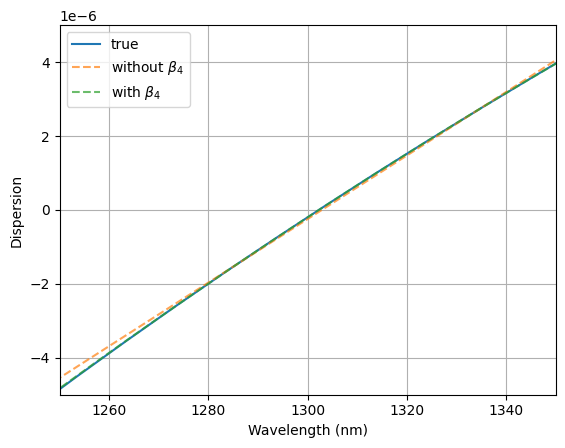

In [47]:
fibre_Furukawa_Allwave_ULL1 = FibreSpanSetupAdvanced(
    length=f'{length}km', dispersion_order=1, dispersion_ref_lambda=reflambda,  # can I just change the dispersion order here? change dispersion_ref_lambda=reflambda
    dispersion_fit_points=jnp.array([1280e-9, 1310e-9, 1340e-9]),  # more than 3 points to enable using all wavelength fitting
    attenuation_profile=data.fit_attenuation('min'),
    # raman_profile=load_g652d_raman(),
    raman_profile=load_corning_smf_28_raman(),
    dispersion_profile=data.get_dispersion('min'),
    effective_area_profile=(jnp.array([1310e-9, 1550e-9]), jnp.array([66.476e-12, 86.59e-12])),
    nonlinear_coeff_profile=(jnp.array([1310e-9]), jnp.array([2e-3]))
    # change
    # A_eff=(jnp.array([1310e-9, 1550e-9]), jnp.array([66.476e-12, 86.59e-12])),
    # nonlinear_coeff=(jnp.array([1310e-9]), jnp.array([2e-3]))
)
fibre_Furukawa_Allwave_ULL2 = FibreSpanSetupAdvanced(
    length=f'{length}km', dispersion_order=2, dispersion_ref_lambda=reflambda,  # can I just change the dispersion order here? change ref_lambda=reflambda
    dispersion_fit_points=jnp.array([1280e-9, 1310e-9, 1340e-9]),  # more than 3 points to enable using all wavelength fitting
    attenuation_profile=data.fit_attenuation('min'),
    # raman_profile=load_g652d_raman(),
    raman_profile=load_corning_smf_28_raman(),
    dispersion_profile=data.get_dispersion('min'),
    # A_eff=(jnp.array([1310e-9, 1550e-9]), jnp.array([66.476e-12, 86.59e-12])),
    # nonlinear_coeff=(jnp.array([1310e-9]), jnp.array([2e-3]))
    # change
    effective_area_profile=(jnp.array([1310e-9, 1550e-9]), jnp.array([66.476e-12, 86.59e-12])),
    nonlinear_coeff_profile=(jnp.array([1310e-9]), jnp.array([2e-3]))
)

dispersion_profile = data.get_dispersion('min')
dispersion_fit1 = fibre_Furukawa_Allwave_ULL1.dispersion_fit_at(dispersion_profile[0])
dispersion_fit2 = fibre_Furukawa_Allwave_ULL2.dispersion_fit_at(dispersion_profile[0])

plt.plot(1e9 * dispersion_profile[0], dispersion_profile[1], '-', label='true')
plt.plot(1e9 * dispersion_profile[0], dispersion_fit1, '--', alpha=0.7, label=r'without ${\beta_4}$')
plt.plot(1e9 * dispersion_profile[0], dispersion_fit2, '--', alpha=0.7, label=r'with ${\beta_4}$')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Dispersion')
plt.xlim(1250, 1350)
plt.ylim(-0.5e-5, 0.5e-5)
plt.legend()
plt.grid()
plt.show()

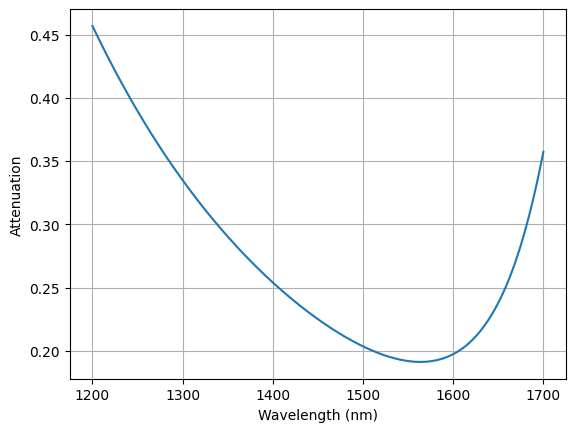

In [48]:
attenuation_profile = data.fit_attenuation('min')

plt.plot(1e9 * attenuation_profile[0], 1e3 * attenuation_profile[1])
# plt.plot(l * 1e9, b2b_snr_db, label='B2B')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Attenuation')
plt.grid()
plt.show()

In [49]:
def calc_beta3(l, S, beta2) -> float:
    """ Dispersion beta3 value """
    return S*l**4/(4*pi**2*c**2) - beta2*l/(pi*c)

def calc_beta4(l, Shat, beta2, beta3) -> float:
    """ Dispersion beta4 value """
    return l*(-Shat*l**5 - 12*pi*beta2*c*l - 24*pi**2*beta3*c**2)/(8*pi**3*c**3)

# dispersion = 0  # [s/m^2]
# dispersion_slope = 0.087e3  # [s/m^3]
# beta2 = -dispersion * reflambda ** 2 / (2 * pi * c)
# beta3 = calc_beta3(reflambda, dispersion_slope, beta2)

dispersion = 0 # [s/m^2]
dispersion_slope = 0.08746e3  # [s/m^3]
dispersion_curvature = -9.714e7  # [s/m^4]
beta2 = -dispersion * reflambda ** 2 / (2 * pi * c)
beta3 = calc_beta3(reflambda, dispersion_slope, beta2)
beta4 = calc_beta4(reflambda, dispersion_curvature, beta2, beta3)
if not b4:
    beta4 = 0

# dispersion = 0e-6  # [s/m^2]
# dispersion_slope = 0.087e3  # [s/m^3]
# beta2 = -dispersion * reflambda ** 2 / (2 * pi * c)
# beta3 = calc_beta3(reflambda, dispersion_slope, beta2)

In [50]:
import jax
import numpy as np
from jax import numpy as jnp
from jax.numpy import exp, sum, sqrt, log, zeros, abs, sign, arcsinh, arctan, nansum, mean, nan_to_num
from scipy.constants import pi, c

_INDICES = (jnp.arange(4)[:, None] >> jnp.arange(2)) & 1
_INDICES_COI = (jnp.arange(16)[:, None] >> jnp.arange(4)) & 1
_INDICES_FWM = (jnp.arange(64)[:, None] >> jnp.arange(6)) & 1

In [51]:
j = 0
chs = jnp.arange(setup.num_channels)
P_channel_W = 10 ** ((P_channel - 30) / 10)

Aeff_i = jnp.array(setup.spans[j].A_eff_at(setup.ch_lambda_ij[chs, j]))
att = setup.attenuation_ij[chs, j]
gamma_i = jnp.array(setup.spans[j].nonlinear_coeff_at(setup.ch_lambda_ij[chs, j]))

num_spans = setup.num_spans
length_j = setup.length_j
attenuation_ij = setup.attenuation_ij
ch_power_W_ij = P_channel_W[:, None]
nonlinear_coeff_j = gamma_i[:, None]
ch_centre_ij = setup.ch_centre_ij
ch_bandwidth_ij = setup.ch_bandwidth_ij
beta2_j = jnp.array([[beta2]])
beta3_j = jnp.array([[beta3]])
beta4_j = jnp.array([[beta4]])

In [52]:
from ong.models.raman_fitting import get_power_profile_fit

Aeff_i = jnp.array(setup.spans[j].A_eff_at(setup.ch_lambda_ij[chs, j]))
att = setup.attenuation_ij[chs, j]

l = setup.length_j[0]
z = jnp.logspace(0, jnp.log10(l), num=jnp.array(l / 1e3 * samples_per_km + 1, dtype=int))

_, power_evo = raman_solver.solve_isrs_evolution(
    ch_centre_i=setup.ch_centre_ij[:, j],
    A_eff=Aeff_i,
    raman_profile=setup.raman_profile_j[j],
    length=setup.length_j[j],
    attenuation_i=att,
    ch_power_W_i=P_channel_W,
    ref_lambda=setup.ref_lambda,
    zspan=z,
)

params = get_power_profile_fit(length_j=length_j,
                               power_evo_j=power_evo[None, :, :],
                               ch_centre_ij=ch_centre_ij,
                               ch_power_W_ij=ch_power_W_ij,
                               attenuation_ij=attenuation_ij,
                               raman_gain_slope_j=setup.raman_gain_slope_j,
                               zspan=z)[:, :, None]

# fit_params = jnp.array(np.loadtxt('fitted_param.txt', delimiter='\t', skiprows=1))[:, :, None]
fit_params = params
a = fit_params[:, 0]
a_bar = fit_params[:, 1]
Cr = fit_params[:, 2]

In [53]:
jnp.repeat(nonlinear_coeff_j[None], num_channels, axis=1).shape

(1, 25921, 1)

In [54]:
L = length_j
P_ij = ch_power_W_ij
Ptot = jnp.sum(P_ij, axis=0)
gamma_ij = nonlinear_coeff_j
if gamma_ij.ndim == 1:
    gamma_ij = jnp.repeat(nonlinear_coeff_j[None], num_channels, axis=1)
fi = ch_centre_ij
Bch = ch_bandwidth_ij
mean_att_i = jnp.mean(a, axis=1)  # average attenuation coefficent for channel i
mean_L = jnp.mean(L)  # average fiber length

a_i = a[:, j:j+1]  # \alpha of COI in fiber span j
a_k = jnp.transpose(a[:, j:j+1])  # \alpha of INT in fiber span j
a_bar_i = a_bar[:, j:j+1]  # \bar{\alpha} of COI in fiber span j
a_bar_k = jnp.transpose(a_bar[:, j:j+1])  # \bar{\alpha} of INT in fiber span j
f_i = fi[:, j:j+1]  # f_i of COI in fiber span j
f_k = jnp.transpose(fi[:, j:j+1])  # f_k of INT in fiber span j
B_i = Bch[:, j:j+1]  # B_i of COI in fiber span j
B_k = jnp.transpose(Bch[:, j:j+1])  # B_k of INT in fiber span j
Cr_i = Cr[:, j:j+1]  # Cr of COI in fiber span j
Cr_k = jnp.transpose(Cr[:, j:j+1])  # Cr of INT in fiber span j
P_i = P_ij[:, j:j+1]  # P_i of COI in fiber span j
P_k = jnp.transpose(P_ij[:, j:j+1])  # P_k of INT in fiber span j

# \phi_i  of COI in fiber span j
phi_i = -4 * pi ** 2 * (beta2_j[j] + pi * beta3_j[j] * (f_i + f_i) + 2 * pi ** 2 * beta4_j[j] * f_i ** 2)

# \phi_ik of COI-INT pair in fiber span j
phi_ik = -4 * pi ** 2 * (f_k - f_i) * (beta2_j[j] + pi * beta3_j[j] * (f_i + f_k) + 2 / 3 * pi ** 2 * beta4_j[j] * (f_i ** 2 + f_i * f_k + f_k ** 2))

Tf_i = (a_i + a_bar_i - f_i * Ptot[j] * Cr_i) ** 2  # T_i of COI in fiber span j
Tf_k = (a_k + a_bar_k - f_k * Ptot[j] * Cr_k) ** 2  # T_k of INT in fiber span j

Tf_i = -((Ptot[j] * Cr_i) / a_bar_i) * f_i
Tf_k = -((Ptot[j] * Cr_k) / a_bar_k) * f_k

T_i = 1 + Tf_i
T_k = 1 + Tf_k

In [55]:
@jax.jit
def _eta_GN_SPM(phi_i, B_i, a, a_bar, gamma, Tf, T, L):
    def _fun(x):
        l, l_line = x
        alpha = a + a_bar * l
        alpha_tilde = (alpha * (1 - exp(-alpha * L))) / (1 - exp(-alpha * L) - alpha * L * exp(-alpha * L))
        alpha_line = a + a_bar * l_line
        alpha_tilde_line = (alpha_line * (1 - exp(-alpha_line * L))) / (1 - exp(-alpha_line * L) - alpha_line * L * exp(-alpha_line * L))
        T_tilde = T * ((-Tf / T) ** l)
        T_tilde_line = T * ((-Tf / T) ** l_line)
        kappa = ((1 - exp(-alpha * L)) ** 2) / (1 - exp(-alpha * L) - alpha * L * exp(-alpha * L))
        kappa_line = ((1 - exp(-alpha_line * L)) ** 2) / (1 - exp(-alpha_line * L) - alpha_line * L * exp(-alpha_line * L))
        idx = (phi_i == 0)
        return (nan_to_num(
            (16 / 27) * gamma ** 2 / B_i ** 2
            * ((2 * kappa * kappa_line * pi * T_tilde * T_tilde_line) / (phi_i * (alpha_tilde + alpha_tilde_line)))
            * (arcsinh(3 * phi_i * B_i ** 2 / (8 * pi * alpha_tilde)) + arcsinh(3 * phi_i * B_i ** 2 / (8 * pi * alpha_tilde_line))),
            nan=0,
            posinf=0,
            neginf=0,
        ) + idx * ((16 / 27) * gamma ** 2 * (kappa * kappa_line * T_tilde * T_tilde_line * (3 / (4 * alpha_tilde * alpha_tilde_line))))).squeeze()

    return jax.vmap(_fun)(_INDICES).sum(axis=0)


@jax.jit
def _eta_GN_XPM(Pi, Pk, phi_ik, B_i, B_k, a, a_bar, gamma, Tf, T, L):
    def _fun(x):
        l, l_line = x
        alpha = a + a_bar * l
        alpha_tilde = alpha * (1 - exp(-alpha * L)) / (1 - exp(-alpha * L) - alpha * L * exp(-alpha * L))
        alpha_line = a + a_bar * l_line
        alpha_tilde_line = alpha_line * (1 - exp(-alpha_line * L)) / (1 - exp(-alpha_line * L) - alpha_line * L * exp(-alpha_line * L))
        kappa = (1 - exp(-alpha * L)) ** 2 / (1 - exp(-alpha * L) - alpha * L * exp(-alpha * L))
        kappa_line = (1 - exp(-alpha_line * L)) ** 2 / (1 - exp(-alpha_line * L) - alpha_line * L * exp(-alpha_line * L))
        T_tilde = T * ((-Tf / T) ** l)
        T_tilde_line = T * ((-Tf / T) ** l_line)
        return 32 / 27 * jnp.sum(
            nan_to_num(
                (Pk / Pi) ** 2 * gamma ** 2 / B_k
                * (kappa * kappa_line * 2 * T_tilde * T_tilde_line / (phi_ik * (alpha_tilde + alpha_tilde_line)))
                * (arctan(phi_ik * B_i / (2 * alpha_tilde)) + arctan(phi_ik * B_i / (2 * alpha_tilde_line))),
                nan=0,
                posinf=0,
                neginf=0,
            ),
            axis=1,
        ).squeeze()

    return jax.vmap(_fun)(_INDICES).sum(axis=0)

In [56]:
def _FWM_idx(f):
    freqs = f.squeeze()

    f_i = freqs[:, None, None, None]
    f_j = freqs[None, :, None, None]
    f_k = freqs[None, None, :, None]
    f_m = freqs[None, None, None, :]
    cond = ((f_j + f_k - f_m) == f_i) & (f_j != f_i) & (f_k != f_m) & (f_k != f_i) & (f_j != f_m) & (f_j <= f_k)
    i_idx, j_idx, k_idx, m_idx = jnp.nonzero(cond)
    idx_flat = jnp.stack([i_idx, j_idx, k_idx, m_idx], axis=-1)
    counts = jnp.bincount(i_idx, length=freqs.size)

    n, K, M = counts.size, idx_flat.shape[0], int(counts.max())
    s = jnp.concatenate([jnp.array([0]), jnp.cumsum(counts)[:-1]])
    ch = jnp.repeat(jnp.arange(n), counts)
    r = jnp.arange(K) - s[ch]
    idx_pad = jnp.zeros((n, M, idx_flat.shape[1]), idx_flat.dtype).at[ch, r].set(idx_flat)
    valid = jnp.zeros((n, M)).at[ch, r].set(True)

    return idx_pad, valid

@jax.jit
def _eta_GN_FWM(Ptot, P, beta2, beta3, beta4, a, a_bar, f, B, Cr, gamma, L, idx_pad, valid):
    def _ch(i):
        idx_ch = idx_pad[i]
        valid_ch = valid[i]
        def _eta_per_ch(Ptot, P, beta2, beta3, beta4, a, a_bar, f, B, Cr, gamma, L, idx_ch, valid_ch):
            T_tilde = -((Ptot * Cr) / (2 * a)) * f
            T = 1 + T_tilde

            def _eta(idx):
                i, j, k, m = idx

                def _phi(i, j, k, f, beta2, beta3, beta4):
                    phi_jk  = -4 * pi ** 2 * (f[j] - f[i]) * (f[k] - f[i]) * (beta2 + pi * beta3 * (f[j] + f[k]) + \
                            (2 / 3) * pi ** 2 * beta4 * (f[j] ** 2 + f[j] * f[k] + f[k] ** 2 + 0.5 * (f[j] - f[i]) * (f[k] - f[i])))
                    dphi_f1 = -4 * pi ** 2 * (f[k] - f[i]) * (beta2 + pi * beta3 * (f[j] + f[k] + f[j] - f[i]) + \
                            (2 / 3) * pi ** 2 * beta4 * (f[j] ** 2 + f[j] * f[k] + f[k] ** 2 + 0.5 * (f[j] - f[i]) * (f[k] - f[i]) + (f[j] - f[i]) * (2 * (f[j] - f[i]) + 1.5 * (f[k] - f[i]) + 3 * f[i])))
                    dphi_f2 = -4 * pi ** 2 * (f[j] - f[i]) * (beta2 + pi * beta3 * (f[j] + f[k] + f[k] - f[i]) + \
                            (2 / 3) * pi ** 2 * beta4 * (f[j]**2 + f[j] * f[k] + f[k] ** 2 + 0.5 * (f[j] - f[i]) * (f[k] - f[i]) + (f[k] - f[i]) * (2 * (f[k] - f[i]) + 1.5 * (f[j] - f[i]) + 3 * f[i])))
                    return phi_jk, dphi_f1, dphi_f2

                phi_jk, dphi_f1, dphi_f2 = _phi(i, j, k, f, beta2, beta3, beta4)

                def _island(i, j, k, m, a, a_bar, T, T_tilde,
                        B, P, gamma, L, phi_jk, dphi_f1, dphi_f2):
                    Omega = jnp.where(j == k, 1, 2)

                    Bi = B[i]; Bj = B[j]; Bk = B[k]; Bm = B[m]
                    Pi = P[i]; Pj = P[j]; Pk = P[k]; Pm = P[m]

                    gamma_i = gamma[i]

                    f1bound = Bj / 2
                    f2min = -Bk / 2
                    f2max = Bk / 2

                    def _F(a, b, d, f2):
                        term_plus = a + b * f2 + d
                        term_minus = a + b * f2 - d
                        return ((term_plus * arctan(term_plus) - term_minus * arctan(term_minus)) / b
                            - 0.5 / b * (log(1.0 + term_plus**2) - log(1.0 + term_minus**2)))

                    def _island_COI(x):
                        l_j, l_k, l_j_line, l_k_line = x

                        alpha_j = a[j] / 2 + l_j * a_bar[j]
                        alpha_k = a[k] / 2 + l_k * a_bar[k]
                        alpha_all = alpha_j + alpha_k

                        alpha_j_line = a[j] / 2 + l_j_line * a_bar[j]
                        alpha_k_line = a[k] / 2 + l_k_line * a_bar[k]
                        alpha_all_line = alpha_j_line + alpha_k_line

                        T_tilde_j = T[j] * (-T_tilde[j] / T[j]) ** l_j
                        T_tilde_k = T[k] * (-T_tilde[k] / T[k]) ** l_k
                        T_tilde_all = T_tilde_j * T_tilde_k

                        T_tilde_j_line = T[j] * (-T_tilde[j] / T[j]) ** l_j_line
                        T_tilde_k_line = T[k] * (-T_tilde[k] / T[k]) ** l_k_line
                        T_tilde_all_line = T_tilde_j_line * T_tilde_k_line

                        alpha_tilde_all = (alpha_all * (1 - exp(-alpha_all * L))
                            / (1 - exp(-alpha_all * L) - alpha_all * L * exp(-alpha_all * L)))
                        kappa_all = ((1 - exp(-alpha_all * L)) ** 2
                            / (1 - exp(-alpha_all * L) - alpha_all * L * exp(-alpha_all * L)))

                        alpha_tilde_all_line = (alpha_all_line * (1 - exp(-alpha_all_line * L))
                            / (1 - exp(-alpha_all_line * L) - alpha_all_line * L * exp(-alpha_all_line * L)))
                        kappa_all_line = ((1 - exp(-alpha_all_line * L)) ** 2
                            / (1 - exp(-alpha_all_line * L) - alpha_all_line * L * exp(-alpha_all_line * L)))

                        a1 = phi_jk / alpha_tilde_all
                        a2 = phi_jk / alpha_tilde_all_line
                        b1 = dphi_f2 / alpha_tilde_all
                        b2 = dphi_f2 / alpha_tilde_all_line

                        d1 = dphi_f1 * f1bound / alpha_tilde_all
                        d2 = dphi_f1 * f1bound / alpha_tilde_all_line

                        F1 = _F(a1, b1, d1, f2max) - _F(a1, b1, d1, f2min)
                        F2 = _F(a2, b2, d2, f2max) - _F(a2, b2, d2, f2min)

                        term = (T_tilde_all * T_tilde_all_line * kappa_all * kappa_all_line
                            / (alpha_tilde_all + alpha_tilde_all_line) * (F1 + F2) / dphi_f1)
                        return term

                    def _island_FWM(x):
                        l_j, l_k, l_m, l_j_line, l_k_line, l_m_line = x

                        alpha_j = a[j] / 2 + l_j * a_bar[j]
                        alpha_k = a[k] / 2 + l_k * a_bar[k]
                        alpha_m = a[m] / 2 + l_m * a_bar[m]
                        alpha_i = a[i] / 2
                        alpha_all = alpha_j + alpha_k + alpha_m - alpha_i

                        alpha_j_line = a[j] / 2 + l_j_line * a_bar[j]
                        alpha_k_line = a[k] / 2 + l_k_line * a_bar[k]
                        alpha_m_line = a[m] / 2 + l_m_line * a_bar[m]
                        alpha_i_line = a[i] / 2
                        alpha_all_line = alpha_j_line + alpha_k_line + alpha_m_line - alpha_i_line

                        T_tilde_j = T[j] * (-T_tilde[j] / T[j]) ** l_j
                        T_tilde_k = T[k] * (-T_tilde[k] / T[k]) ** l_k
                        T_tilde_m = T[m] * (-T_tilde[m] / T[m]) ** l_m
                        T_tilde_all = T_tilde_j * T_tilde_k * T_tilde_m

                        T_tilde_j_line = T[j] * (-T_tilde[j] / T[j]) ** l_j_line
                        T_tilde_k_line = T[k] * (-T_tilde[k] / T[k]) ** l_k_line
                        T_tilde_m_line = T[m] * (-T_tilde[m] / T[m]) ** l_m_line
                        T_tilde_all_line = T_tilde_j_line * T_tilde_k_line * T_tilde_m_line

                        alpha_tilde_all = (alpha_all * (1 - exp(-alpha_all * L))
                            / (1 - exp(-alpha_all * L) - alpha_all * L * exp(-alpha_all * L)))
                        kappa_all = ((1 - exp(-alpha_all * L)) ** 2
                            / (1 - exp(-alpha_all * L) - alpha_all * L * exp(-alpha_all * L)))

                        alpha_tilde_all_line = (alpha_all_line * (1 - exp(-alpha_all_line * L))
                            / (1 - exp(-alpha_all_line * L) - alpha_all_line * L * exp(-alpha_all_line * L)))
                        kappa_all_line = ((1 - exp(-alpha_all_line * L)) ** 2
                            / (1 - exp(-alpha_all_line * L) - alpha_all_line * L * exp(-alpha_all_line * L)))

                        a1 = phi_jk / alpha_tilde_all
                        a2 = phi_jk / alpha_tilde_all_line
                        b1 = dphi_f2 / alpha_tilde_all
                        b2 = dphi_f2 / alpha_tilde_all_line

                        d1 = dphi_f1 * f1bound / alpha_tilde_all
                        d2 = dphi_f1 * f1bound / alpha_tilde_all_line

                        F1 = _F(a1, b1, d1, f2max) - _F(a1, b1, d1, f2min)
                        F2 = _F(a2, b2, d2, f2max) - _F(a2, b2, d2, f2min)

                        term = (T_tilde_all * T_tilde_all_line * kappa_all * kappa_all_line
                            / (alpha_tilde_all + alpha_tilde_all_line) * (F1 + F2) / dphi_f1)
                        return term

                    sum = jax.lax.cond(
                        m == i,
                        lambda _: jax.vmap(_island_COI)(_INDICES_COI).sum(axis=0),
                        lambda _: jax.vmap(_island_FWM)(_INDICES_FWM).sum(axis=0),
                        operand=None
                    )

                    eta_jkm = nan_to_num(
                        Omega * (16 / 27) * gamma_i ** 2 * (Bi / Pi ** 3)
                        * (Pj * Pk * Pm / (Bj * Bk * Bm)) * sum,
                        nan=0,
                        posinf=0,
                        neginf=0
                        )

                    return eta_jkm

                return _island(i, j, k, m, a, a_bar, T, T_tilde, B, P, gamma, L, phi_jk, dphi_f1, dphi_f2)

            return jnp.where(valid_ch, jax.vmap(_eta)(idx_ch).squeeze(), 0).sum(axis=0)
        
        return _eta_per_ch(Ptot, P, beta2, beta3, beta4, a, a_bar, f, B, Cr, gamma, L, idx_ch, valid_ch)
    
    return jax.lax.map(_ch, jnp.arange(f.size))


In [57]:
_eta_SPM = _eta_GN_SPM(phi_i, B_i, a_i, a_bar_i, gamma_ij[:, j], Tf_i, T_i, length_j[j])
_eta_XPM = _eta_GN_XPM(P_i, P_k, phi_ik, B_i, B_k, a_k, a_bar_k, gamma_ij[:, j], Tf_k, T_k, length_j[j])

In [58]:
idx_pad, valid = _FWM_idx(f_i)
_eta_FWM = _eta_GN_FWM(Ptot, P_i, beta2_j[j], beta3_j[j], beta4_j[j], a_i, a_i, f_i, B_i, Cr_i, gamma_ij[:, j], length_j[j], idx_pad, valid)
#change a_i, a_i,->a_i, a_bar_i

In [66]:
print("_eta_SPM shape:", jnp.shape(_eta_SPM), "ndim:", jnp.ndim(_eta_SPM))
print("_eta_XPM shape:", jnp.shape(_eta_XPM), "ndim:", jnp.ndim(_eta_XPM))
print("_eta_FWM shape:", jnp.shape(_eta_FWM), "ndim:", jnp.ndim(_eta_FWM))

_eta_SPM shape: (161, 161) ndim: 2
_eta_XPM shape: (161,) ndim: 1
_eta_FWM shape: (161,) ndim: 1


In [63]:
print(_eta_SPM)


[[18.27206855 18.27206855 18.27206855 ... 18.27206855 18.27206855
  18.27206855]
 [18.25341824 18.25341824 18.25341824 ... 18.25341824 18.25341824
  18.25341824]
 [18.23490507 18.23490507 18.23490507 ... 18.23490507 18.23490507
  18.23490507]
 ...
 [12.6506776  12.6506776  12.6506776  ... 12.6506776  12.6506776
  12.6506776 ]
 [12.5993262  12.5993262  12.5993262  ... 12.5993262  12.5993262
  12.5993262 ]
 [12.5483808  12.5483808  12.5483808  ... 12.5483808  12.5483808
  12.5483808 ]]


In [64]:
print(_eta_XPM)

[ 287.73823853  324.61413073  355.33439073  390.4642157   439.43817287
  473.45217996  497.3513314   516.71403442  533.67753001  549.25511624
  563.96427054  578.05958845  591.65384039  604.79720387  617.53592222
  629.94563383  642.13235237  654.21393028  666.29733549  678.46047738
  690.74863296  703.17913469  715.7477416   728.44257562  741.25416408
  754.18190935  767.23972048  780.45355523  793.85621909  807.48396164
  821.37035144  835.54337658  850.02620584  864.83607639  879.98694927
  895.49235608  911.36461904  927.61851274  944.27237721  961.34535635
  978.86033924  996.84298792 1015.31900566 1034.31639779 1053.86420888
 1073.99105406 1094.72711326 1116.10299979 1138.14936485 1160.89857666
 1184.38295149 1208.63493571 1233.68841955 1259.57604224 1286.32933476
 1313.97909267 1342.55152727 1372.06807861 1402.54415839 1433.98303851
 1466.37375965 1499.68565238 1533.85705032 1568.78538288 1604.30689957
 1640.16101646 1675.9339994  1710.95339862 1744.11030852 1773.61501507
 1796.

In [65]:

print(_eta_FWM)

[   5.7929449    13.3098132    46.87752525  103.63322198  186.32342806
  220.89393794  243.9896032   261.44442151  275.65275904  287.26841677
  296.68357005  304.4349329   311.19713747  317.78871416  325.32637822
  334.4660633   344.840035    355.54511409  365.94944816  375.73340071
  384.73157114  392.95972126  400.58689591  407.86512498  415.14842111
  423.09535178  432.32606087  442.70156937  454.31868445  466.69998325
  479.33649889  491.98115929  504.54380354  516.99527134  529.35873043
  541.70857731  554.13379676  566.73045172  579.64531548  593.12573545
  607.55578688  623.35679922  640.77908435  659.86977523  680.50245037
  702.45368757  725.56327662  749.76572057  775.11671673  801.72278572
  829.74064445  859.33659379  890.71833353  924.11461622  959.77651936
  998.01401339 1039.15579233 1083.59437066 1131.80015425 1184.30420985
 1241.75694258 1304.95775046 1374.87643666 1452.72909469 1540.09360038
 1638.99494105 1752.14458181 1883.21843077 2037.16598848 2220.27282502
 2438.

In [59]:
# a = a_i
# a_bar = a_i
# B = B_i
# P = P_i
# gamma = gamma_ij[:, j]
# L = length_j[j]


# Omega = jnp.where(j == k, 1, 2)

# Bj = B[j]
# Bk = B[k]
# Bm = B[m]
# Bi = B[i]

# Pj = P[j]
# Pk = P[k]
# Pm = P[m]
# Pi = P[i]

# gamma_i = gamma[i]

# f1bound = Bj / 2.0
# f2min = -Bk / 2.0
# f2max = Bk / 2.0

# bits = _INDICES_FWM[0]

# l_j, l_k, l_m, l_j_line, l_k_line, l_m_line = bits

# alpha_j = a[j] / 2.0 + l_j * a_bar[j]
# alpha_k = a[k] / 2.0 + l_k * a_bar[k]
# alpha_m = a[m] / 2.0 + l_m * a_bar[m]
# alpha_i = a[i] / 2.0
# alpha_all = alpha_j + alpha_k + alpha_m - alpha_i

# alpha_j_line = a[j] / 2.0 + l_j_line * a_bar[j]
# alpha_k_line = a[k] / 2.0 + l_k_line * a_bar[k]
# alpha_m_line = a[m] / 2.0 + l_m_line * a_bar[m]
# alpha_i_line = a[i] / 2.0
# alpha_all_line = alpha_j_line + alpha_k_line + alpha_m_line - alpha_i_line

# T_tilde_j = T[j] * (-T_tilde[j] / T[j]) ** l_j
# T_tilde_k = T[k] * (-T_tilde[k] / T[k]) ** l_k
# T_tilde_m = T[m] * (-T_tilde[m] / T[m]) ** l_m
# T_tilde_all = T_tilde_j * T_tilde_k * T_tilde_m

# T_tilde_j_line = T[j] * (-T_tilde[j] / T[j]) ** l_j_line
# T_tilde_k_line = T[k] * (-T_tilde[k] / T[k]) ** l_k_line
# T_tilde_m_line = T[m] * (-T_tilde[m] / T[m]) ** l_m_line
# T_tilde_all_line = T_tilde_j_line * T_tilde_k_line * T_tilde_m_line

# alpha_tilde_all = (
#     alpha_all * (1.0 - jnp.exp(-alpha_all * L))
#     / (
#         1.0
#         - jnp.exp(-alpha_all * L)
#         - alpha_all * L * jnp.exp(-alpha_all * L)
#     )
# )
# kappa_all = (
#     (1.0 - jnp.exp(-alpha_all * L)) ** 2
#     / (
#         1.0
#         - jnp.exp(-alpha_all * L)
#         - alpha_all * L * jnp.exp(-alpha_all * L)
#     )
# )

# alpha_tilde_all_line = (
#     alpha_all_line * (1.0 - jnp.exp(-alpha_all_line * L))
#     / (
#         1.0
#         - jnp.exp(-alpha_all_line * L)
#         - alpha_all_line * L * jnp.exp(-alpha_all_line * L)
#     )
# )
# kappa_all_line = (
#     (1.0 - jnp.exp(-alpha_all_line * L)) ** 2
#     / (
#         1.0
#         - jnp.exp(-alpha_all_line * L)
#         - alpha_all_line * L * jnp.exp(-alpha_all_line * L)
#     )
# )

# a1 = phi_jk / alpha_tilde_all
# a2 = phi_jk / alpha_tilde_all_line
# b1 = dphi_f2 / alpha_tilde_all
# b2 = dphi_f2 / alpha_tilde_all_line

# d1 = dphi_f1 * f1bound / alpha_tilde_all
# d2 = dphi_f1 * f1bound / alpha_tilde_all_line

# F1 = F_antiderivative(a1, b1, d1, f2max) - F_antiderivative(a1, b1, d1, f2min)
# F2 = F_antiderivative(a2, b2, d2, f2max) - F_antiderivative(a2, b2, d2, f2min)

# term = (
#     T_tilde_all
#     * T_tilde_all_line
#     * kappa_all
#     * kappa_all_line
#     / (alpha_tilde_all + alpha_tilde_all_line)
#     * (F1 + F2)
#     / dphi_f1
# )